<a href="https://colab.research.google.com/github/Gayathri280278HARI/House-price-prediction/blob/main/Multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   area  bedrooms  age    price
0  1000         2   10  2000000
1  1500         3    5  3000000
2  1800         4    8  4500000
3  2400         5    2  5000000
4  3000         5    1  5500000
Coefficients: [8.06261075e+02 9.39013585e+05 1.17936602e+05]
Intercept: -1745668.4386690315
Predicted Price: 3304882.8509549126


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


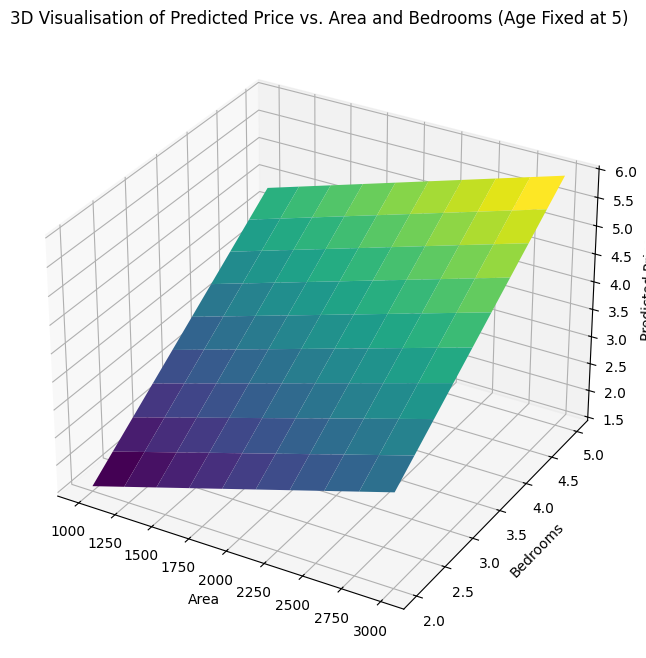

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
data= {
    "area":[1000,1500,1800,2400,3000],
    "bedrooms":[2,3,4,5,5],
    "age":[10,5,8,2,1],
    "price":[2000000,3000000,4500000,5000000,5500000]
}
df=pd.DataFrame(data)
print(df)
X =df[["area","bedrooms","age"]]
Y = df["price"]
model = LinearRegression()
model.fit(X,Y)
print("Coefficients:",model.coef_)
print("Intercept:",model.intercept_)
new_house_area=1600
new_house_bedrooms=3
new_house_age=8
# Create a DataFrame for the new house features, matching the columns used for training
new_house_features = pd.DataFrame([[
    new_house_area,
    new_house_bedrooms,
    new_house_age
]], columns=X.columns)
predicted_price=model.predict(new_house_features)
print("Predicted Price:",predicted_price[0])

# Generate meshgrid for plotting
area_range = np.linspace(df["area"].min(), df["area"].max(), 10)
bed_range = np.linspace(df["bedrooms"].min(), df["bedrooms"].max(), 10)
area_grid, bed_grid = np.meshgrid(area_range, bed_range)
age_fixed = 5 # Assuming a fixed age for 3D visualization with two variables

# Predict prices over the grid
# Flatten the grids and combine with the fixed age
# np.c_ stacks 1-D arrays as columns into a 2-D array
# np.full creates an array of the given shape filled with age_fixed
grid_for_prediction = np.c_[area_grid.ravel(), bed_grid.ravel(), np.full(area_grid.ravel().shape, age_fixed)]

pred_grid_flat = model.predict(grid_for_prediction)

# Reshape the predicted prices back into a 2D grid matching area_grid and bed_grid
pred_grid = pred_grid_flat.reshape(area_grid.shape)

fig = plt.figure(figsize=(10, 8)) # Add figsize for better visualization
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(area_grid, bed_grid, pred_grid, cmap='viridis') # Add colormap for better visualization

ax.set_xlabel("Area")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Predicted Price") # Changed zlabel to Predicted Price as pred_grid is price
plt.title("3D Visualisation of Predicted Price vs. Area and Bedrooms (Age Fixed at 5)") # More descriptive title
plt.show()